# ICT-12d — Animat inhibé (Laborit) : contrôlabilité, rigidification, dette d'irréversibilité (#7741)

**Sous-série ICT** (trajectoires intégrées, Epic #4588). Notebook compagnon du module [`ict.inhibited_action`](ict/inhibited_action.py) (PR [#8825](https://github.com/jsboige/CoursIA/pull/8825)). **Jambe C2** de la tresse transverse — *parallèle* à [C1 — ICT-12c](ICT-12c-PregnanceAnimat.ipynb) (prégnance/valence incarnée, #7740), et distincte d'[ICT-30](ICT-30-InhibitedInvention.ipynb) (inhibition de l'**innovation**, strate 7 collective, #7746) : ici l'inhibition porte sur l'**action** d'un animat individuel (strate 3/5).

## Le maillon Laborit

Henri Laborit (*L'Éloge de la fuite*, 1976) : des rats soumis à des chocs développent une hypertension durable surtout quand **ni fuite ni action défensive** ne sont possibles. Ce n'est pas le choc qui pathologise, c'est l'**inhibition de l'action** — « le système apprend que ses actions ne contrôlent plus son environnement ». L'analogue formel est un animat dont les actions, à mesure que la **contrôlabilité** s'effondre, deviennent **sans effet** sur la transition d'état, et qui, le détectant, **rigidifie** sa politique.

Ce notebook incarne ce maillon comme un substrat expérimental **falsifiable** (substrat + bancs dans `ict.inhibited_action`), puis le relie quantitativement à la **dette d'irréversibilité** $I(R)$ d'[ICT-18](ICT-18-ArrowOfTimeReversibilization.ipynb). Quatre verdicts falsifiables, chacun avec son contrôle négatif.

> *Portée honnête* : la rencontre avec la strate 7 (inhibition de l'**innovation**, ICT-30) est une issue ultérieure ; ce notebook reste au niveau **animat** (strate 3/5). La lecture post-structuraliste (Foucault/Derrida/Serres) de la boucle signifiant/signifié = générateur de modèles, hors scope expérimental (spec #7741).


In [1]:
import sys, os
sys.path.insert(0, os.getcwd())  # ICT-Series/ pour `from ict import ...`

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from ict.inhibited_action import (
    InhibitedEnvironment,
    estimate_controllability,
    adaptive_animat,
    action_entropy,
    state_coverage,
    rigidification_test,
    goal_seeking_efficacy_test,
    controllability_estimation_test,
    irreversibility_debt_bridge,
)

matplotlib.rcParams["figure.dpi"] = 110
print("module ict.inhibited_action charge (jambe C2, #7741)")


module ict.inhibited_action charge (jambe C2, #7741)


## 1. Le substrat : un anneau contrôlable ou inhibé

L'environnement est un anneau d'états $\{0, \dots, n{-}1\}$ (la 1-torus, minimale). L'action $a \in \{-1, 0, +1\}$ déplace l'animat. La **contrôlabilité** $\alpha \in [0,1]$ est le bouton de Laborit :

- avec probabilité $\alpha$, l'action est **appliquée** (l'animat contrôle) ;
- avec probabilité $1-\alpha$, l'action est **ignorée** et l'état dérive d'un pas aléatoire (inhibition).

$\alpha = 1$ : contrôle total. $\alpha = 0$ : **inhibition totale** — l'animat peut bien « choisir », son choix n'a aucun effet sur le suivant. Démontrons-le : un animat qui cherche à rejoindre l'état 0 (politique greedy) y parvient sous $\alpha=1$, et erre sous $\alpha=0$.


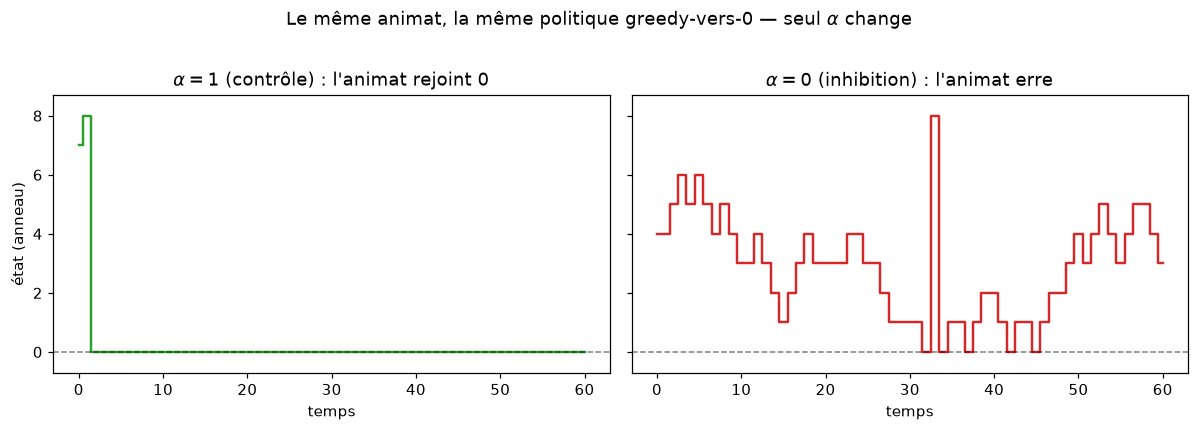

couverture états  alpha=1 : 3 / 9
couverture états  alpha=0 : 8 / 9


In [2]:
n_states = 9
n_steps = 60

def greedy_toward(state, n=n_states):
    fwd = (0 - state) % n
    if fwd == 0:
        return 0
    return 1 if fwd <= n // 2 else -1

def run_homing(alpha, seed):
    rng = np.random.default_rng(seed)
    env = InhibitedEnvironment(n_states, alpha=alpha, drift="uniform", rng=rng)
    s = int(rng.integers(0, n_states))
    traj = [s]
    for _ in range(n_steps):
        a = greedy_toward(s)
        s = env.transition(s, a)
        traj.append(s)
    return np.array(traj)

traj_ctrl = run_homing(1.0, 0)
traj_inh = run_homing(0.0, 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, traj, title, col in [
    (axes[0], traj_ctrl, r"$\alpha=1$ (contrôle) : l'animat rejoint 0", "C2"),
    (axes[1], traj_inh, r"$\alpha=0$ (inhibition) : l'animat erre", "C3"),
]:
    ax.step(np.arange(len(traj)), traj, where="mid", lw=1.6, color=col)
    ax.axhline(0, color="k", ls="--", lw=1, alpha=0.5)
    ax.set_xlabel("temps"); ax.set_title(title)
    ax.set_ylim(-0.7, n_states - 0.3)
axes[0].set_ylabel("état (anneau)")
fig.suptitle(r"Le même animat, la même politique greedy-vers-0 — seul $\alpha$ change", y=1.02)
fig.tight_layout(); plt.show()

print("couverture états  alpha=1 :", len(set(traj_ctrl.tolist())), "/", n_states)
print("couverture états  alpha=0 :", len(set(traj_inh.tolist())), "/", n_states)


## 2. Détection : l'animat « apprend » qu'il ne contrôle plus

Le prérequis de l'inhibition de Laborit est la **détection** : sans elle, pas de « savoir que mes actions ne contrôlent plus ». `estimate_controllability` estime $\alpha$ depuis les transitions observées en comparant le déplacement signé à l'action, **corrigé de la ligne de chance** (la dérive n'est pas uniforme sur les états mais sur les pas $\{-1,0,+1\}$ — un estimateur naïf sur-estimerait $\alpha$).

**Verdict falsifiable** : $|\hat\alpha - \alpha_\text{true}| < 0.1$ pour $\alpha \in \{0, 0.5, 1\}$. Un estimateur aveugle (constant 0.5) raterait $\alpha=0$ et $\alpha=1$.


  abs_err_alpha_0.0            = 0.000
  abs_err_alpha_0.5            = 0.028
  abs_err_alpha_1.0            = 0.000
  max_abs_err                  = 0.028
  detected                     = 1.000

VERDICT 'detected' = 1  (max |erreur| = 0.028 < 0.1)


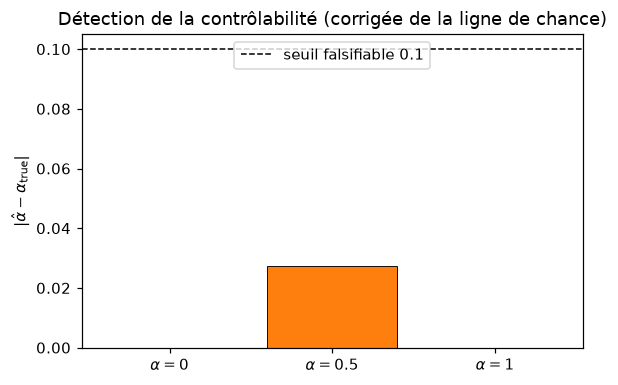

In [3]:
v2 = controllability_estimation_test(n_states=9, n_steps=2000, seed=0)
for k, val in v2.items():
    print(f"  {k:28} = {val:.3f}" if isinstance(val, float) else f"  {k:28} = {val}")
print()
print("VERDICT 'detected' =", int(v2['detected']),
      " (max |erreur| =", round(v2['max_abs_err'], 3), "< 0.1)")

alphas = [0.0, 0.5, 1.0]
errs = [v2["abs_err_alpha_%.1f" % a] for a in alphas]
fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.bar([r"$\alpha=0$", r"$\alpha=0.5$", r"$\alpha=1$"], errs,
       color=["C3", "C1", "C2"], edgecolor="k", lw=0.6)
ax.axhline(0.1, color="k", ls="--", lw=1, label="seuil falsifiable 0.1")
ax.set_ylabel(r"$|\hat\alpha - \alpha_\mathrm{true}|$")
ax.set_title("Détection de la contrôlabilité (corrigée de la ligne de chance)")
ax.legend(loc="upper center")
fig.tight_layout(); plt.show()


## 3. Rigidification : la pathologie de Laborit

Sous $\alpha=0$, l'animat détecte $\hat c \to 0$ et **se replie sur le no-op** (action 0) — c'est l'inhibition adaptative. Sa diversité d'action s'effondre : l'**entropie de Shannon** de la distribution d'action passe de $\ln 3 \approx 1.099$ (exploration) à $\approx 0$ (répétition stérile). Sous $\alpha=1$, $\hat c$ reste élevé et l'animat explore.

**Verdict falsifiable** : `rigidified` ssi la chute d'entropie $H(\alpha{=}1) - H(\alpha{=}0) > 0.3$ nat. Un animat qui n'inhiberait pas garderait la même diversité — le test le détecterait.


  action_entropy_controlled        = 1.097
  action_entropy_inhibited         = 0.268
  entropy_drop                     = 0.830
  chat_mean_controlled             = 1.000
  chat_mean_inhibited              = 0.123
  rigidified                       = 1.000

VERDICT 'rigidified' = 1  (chute d'entropie = 0.83 > 0.3)


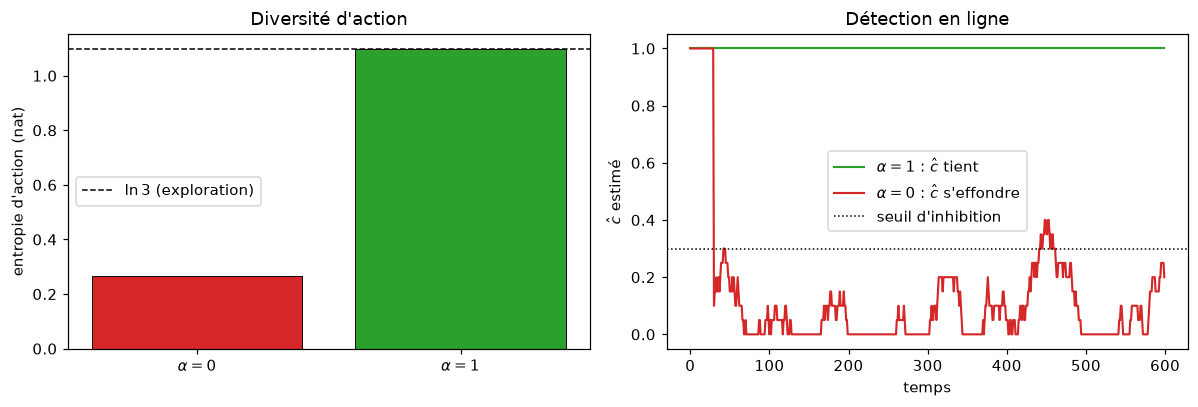

In [4]:
v3 = rigidification_test(n_states=9, n_steps=600, inhibit_threshold=0.3, seed=0)
for k, val in v3.items():
    print(f"  {k:32} = {val:.3f}" if isinstance(val, float) else f"  {k:32} = {val}")
print()
print("VERDICT 'rigidified' =", int(v3['rigidified']),
      " (chute d'entropie =", round(v3['entropy_drop'], 3), "> 0.3)")

# Trace chat au cours du temps pour les deux regimes (pour le panel).
rng0 = np.random.default_rng(0); rng1 = np.random.default_rng(1)
env0 = InhibitedEnvironment(9, alpha=0.0, rng=rng0)
env1 = InhibitedEnvironment(9, alpha=1.0, rng=rng1)
_, _, chat0 = adaptive_animat(env0, 600, 0.3, rng=rng0)
_, _, chat1 = adaptive_animat(env1, 600, 0.3, rng=rng1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar([r"$\alpha=0$", r"$\alpha=1$"],
            [v3["action_entropy_inhibited"], v3["action_entropy_controlled"]],
            color=["C3", "C2"], edgecolor="k", lw=0.6)
axes[0].axhline(np.log(3), color="k", ls="--", lw=1, label=r"$\ln 3$ (exploration)")
axes[0].set_ylabel("entropie d'action (nat)")
axes[0].set_title("Diversité d'action"); axes[0].legend()
t = np.arange(len(chat1))
axes[1].plot(t, chat1, "C2-", lw=1.4, label=r"$\alpha=1$ : $\hat c$ tient")
axes[1].plot(t, chat0, "C3-", lw=1.4, label=r"$\alpha=0$ : $\hat c$ s'effondre")
axes[1].axhline(0.3, color="k", ls=":", lw=1, label="seuil d'inhibition")
axes[1].set_xlabel("temps"); axes[1].set_ylabel(r"$\hat c$ estimé")
axes[1].set_title("Détection en ligne"); axes[1].legend()
fig.tight_layout(); plt.show()


## 4. Perte d'efficacité : l'animat ne peut plus atteindre ni maintenir un but

La couverture d'états ne s'effondre pas sous inhibition (la dérive porte l'animat partout sur un petit anneau) — ce n'est donc pas la bonne pathologie. Celle de Laborit est la **perte d'efficacité de l'action orientée but** : même en cherchant activement à se rendre à la cible (état 0 et ses voisins), l'animat inhibé n'y séjourne plus.

**Verdict falsifiable** : `lost_control` ssi la fraction de pas dans la cible est strictement supérieure sous $\alpha=1$ que sous $\alpha=0$.


  target_fraction_controlled     = 1.000
  target_fraction_inhibited      = 0.294
  efficacy_drop                  = 0.706
  lost_control                   = 1.000

VERDICT 'lost_control' = 1  (baisse d'efficacité = 0.706 )


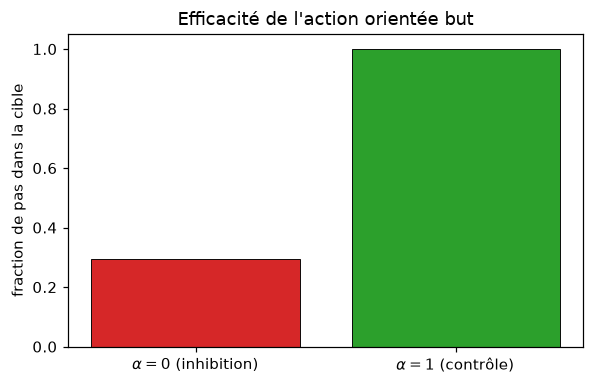

In [5]:
v4 = goal_seeking_efficacy_test(n_states=9, n_steps=800, seed=0)
for k, val in v4.items():
    print(f"  {k:30} = {val:.3f}" if isinstance(val, float) else f"  {k:30} = {val}")
print()
print("VERDICT 'lost_control' =", int(v4['lost_control']),
      " (baisse d'efficacité =", round(v4['efficacy_drop'], 3), ")")

fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.bar([r"$\alpha=0$ (inhibition)", r"$\alpha=1$ (contrôle)"],
       [v4["target_fraction_inhibited"], v4["target_fraction_controlled"]],
       color=["C3", "C2"], edgecolor="k", lw=0.6)
ax.set_ylabel("fraction de pas dans la cible")
ax.set_title("Efficacité de l'action orientée but")
ax.set_ylim(0, 1.05)
fig.tight_layout(); plt.show()


## 5. Le pont $I(R)$ : la dette d'irréversibilité échappe à l'action

Le pont vers la dette d'irréversibilité $I(R)$ (cf. [ICT-18](ICT-18-ArrowOfTimeReversibilization.ipynb), `ict.reversibility_budget.work_budget`) n'est pas « la dette monte sous inhibition » : une permutation déterministe porte *aussi* une forte flèche du temps. Le finding est plus fin — **sous inhibition ($\alpha=0$), changer d'action ne change plus la dette subie** : l'animat a perdu toute prise sur l'irréversibilité qu'il subit, devenue dictée par la dérive seule. À contrôlabilité partielle ($\alpha=0.5$), l'action modulait encore cette dette.

**Verdict falsifiable** : `trapped` ssi (a) l'effet de l'action sur la dette est nul sous inhibition ($|\Delta| < 10^{-9}$), ET (b) non-négligeable à contrôle partiel ($|\Delta(\alpha{=}0.5)| > 0.5$) — preuve que l'action était opérante puis a cessé de l'être.


  debt_inhibited_action_plus1        = 3.000
  debt_inhibited_action_minus1       = 3.000
  debt_partial_action_plus1          = 3.750
  debt_partial_action_minus1         = 0.750
  debt_controlled_action_plus1       = 4.500
  debt_controlled_action_minus1      = 4.500
  action_effect_inhibited            = 0.000
  action_effect_partial_control      = 3.000
  trapped                            = 1.000

VERDICT 'trapped' = 1  (effet action : 0.0 sous inhibition vs 3.0 à contrôle partiel)


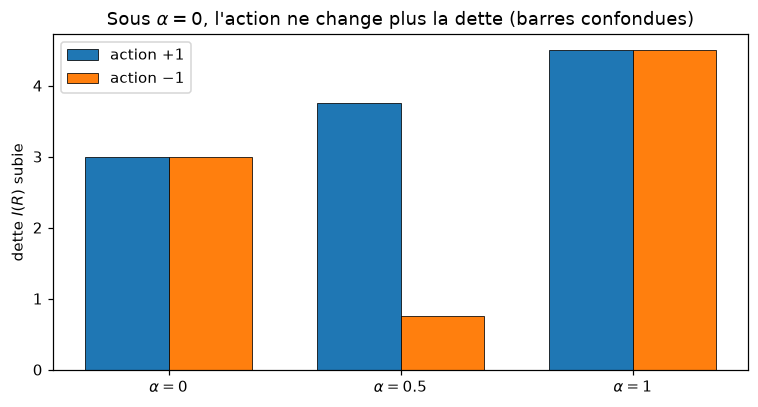

In [6]:
v5 = irreversibility_debt_bridge(n_states=9)
for k, val in v5.items():
    print(f"  {k:34} = {val:.3f}" if isinstance(val, float) else f"  {k:34} = {val}")
print()
print("VERDICT 'trapped' =", int(v5['trapped']),
      " (effet action :", round(v5['action_effect_inhibited'], 3), "sous inhibition vs",
      round(v5['action_effect_partial_control'], 3), "à contrôle partiel)")

labels = [r"$\alpha=0$", r"$\alpha=0.5$", r"$\alpha=1$"]
plus1 = [v5["debt_inhibited_action_plus1"], v5["debt_partial_action_plus1"], v5["debt_controlled_action_plus1"]]
minus1 = [v5["debt_inhibited_action_minus1"], v5["debt_partial_action_minus1"], v5["debt_controlled_action_minus1"]]
x = np.arange(len(labels)); w = 0.36
fig, ax = plt.subplots(figsize=(7.0, 3.8))
ax.bar(x - w/2, plus1, w, label=r"action $+1$", color="C0", edgecolor="k", lw=0.5)
ax.bar(x + w/2, minus1, w, label=r"action $-1$", color="C1", edgecolor="k", lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel(r"dette $I(R)$ subie")
ax.set_title(r"Sous $\alpha=0$, l'action ne change plus la dette (barres confondues)")
ax.legend()
fig.tight_layout(); plt.show()


## 6. Synthèse — la factorisation 4-objets et le seuil de bascule

Les quatre verdicts se laissent lire sur la [factorisation 4-objets](../../../docs/ict/dissociations-matrix.md) $(s, q, \pi, W)$ : l'inhibition de l'action attaque l'**opérateur de workspace** $W$ (l'animat ne peut plus *agir en retour* sur la totalité), puis, par rétroaction, la **prégnance/valence** $\pi$ (rigidification) et la **représentation prédictive** $q$ (perte d'efficacité). C'est l'envers de la [dissociation $\hat p / \pi$ d'ICT-12c](ICT-12c-PregnanceAnimat.ipynb) : là-bas on séparait deux grandeurs qui *tiennent* ; ici on montre une grandeur ($W$) qui *s'effondre*, et emporte les autres.

Le **seuil de bascule** est la contrôlabilité $\alpha_c$ en-dessous de laquelle l'animat inhibe — l'analogue, au niveau animat, du seuil de performativité $\rho_c$ du [cadrage strate 7](ICT-0-Framing.md) (D1/D2). Sa rencontre avec l'inhibition de l'**innovation** collective (ICT-30, #7746) est l'issue ultérieure.


In [7]:
import pandas as pd
rows = [
    ("Détection",         "detected",      r"$|\hat\alpha - \alpha| < 0.1$ sur 3 régimes",        int(v2["detected"])),
    ("Rigidification",    "rigidified",    r"$H(\alpha{=}1) - H(\alpha{=}0) > 0.3$ nat",           int(v3["rigidified"])),
    ("Perte d'efficacité", "lost_control", r"fraction-cible $\alpha{=}1 > \alpha{=}0$",             int(v4["lost_control"])),
    ("Pont $I(R)$",       "trapped",       r"effet action nul sous $\alpha{=}0$, opérant à $0.5$", int(v5["trapped"])),
]
df = pd.DataFrame(rows, columns=["mesure", "verdict", "critère falsifiable", "observé"])
df


,mesure,verdict,critère falsifiable,observé
0,Détection,detected,$|\hat\alpha - \alpha| < 0.1$ sur 3 régimes,1
1,Rigidification,rigidified,$H(\alpha{=}1) - H(\alpha{=}0) > 0.3$ nat,1
2,Perte d'efficacité,lost_control,fraction-cible $\alpha{=}1 > \alpha{=}0$,1
3,Pont $I(R)$,trapped,"effet action nul sous $\alpha{=}0$, opérant à ...",1


## 7. Exercices

### Exercice 1 — Seuil d'inhibition $\alpha_c$

Tracez l'entropie d'action finale en fonction de $\alpha \in \{0, 0.1, \dots, 1\}$ (fixez `n_steps=600`, moyenné sur 3 seeds). Identifiez le **seuil de bascule** $\alpha_c$ où l'animat bascule d'explorateur à inhibé. Ce seuil dépend-il de `inhibit_threshold` ? De `n_states` ?

### Exercice 2 — Dérive hostile (`biased`)

Remplacez `drift="uniform"` par `drift="biased"` (environnement qui pousse dans un sens). L'animat peut-il *exploiter* une dérive orientée pour atteindre la cible même sous faible $\alpha$ ? Mesurez la fraction-cible dans les deux régimes de dérive. Que dit le pont $I(R)$ ?

### Exercice 3 — Inhibition sans détection

Construisez un animat qui **n'estime pas** $\alpha$ (politique fixe aléatoire, sans repli sur le no-op). Comparez son entropie d'action sous $\alpha=0$ à celle de l'animat adaptatif. La rigidification de Laborit est-elle une pathologie de l'**estimation** ou de l'**environnement** ?


In [8]:
# Exercice 1 — squelette.
# alphas = np.arange(0, 1.01, 0.1)
# for a in alphas:
#     ...  # adapter rigidification_test ou appeler adaptive_animat directement
# print("a completer")

# Exercice 2 — squelette.
# for drift in ("uniform", "biased"):
#     ...  # goal_seeking_efficacy_test n'expose pas drift -> appel direct
# print("a completer")

# Exercice 3 — squelette.
# ...  # animat non-adaptatif : actions uniformes sans condition sur chat
# print("a completer")


## Conclusion

**Ce notebook incarne le maillon « animat inhibé » de l'échelle Laborit** (animat simple → *animat inhibé* → agent augmenté → agent créateur → collectif) comme un substrat expérimental falsifiable, et en livre quatre verdicts contrôlés :

1. **Détection** — l'animat estime $\alpha$ depuis ses transitions (corrigé de la ligne de chance) ;
2. **Rigidification** — sous inhibition, sa politique se replie et la diversité d'action s'effondre ;
3. **Perte d'efficacité** — il ne peut plus atteindre ni maintenir un but, quand bien même il le cherche ;
4. **Pont $I(R)$** — l'action ne module plus la dette d'irréversibilité subie, preuve qu'elle a cessé d'être opérante.

**Portée honnête** : substrat 1-torus minimal (anneau à 9 états) — l'objet est la *mécanique* de l'inhibition de l'action (détection → rigidification → perte de prise sur $I(R)$), transposable à des animats richer. La rencontre avec la strate 7 (inhibition de l'**innovation**, [ICT-30](ICT-30-InhibitedInvention.ipynb), #7746) est une issue ultérieure ; ce notebook reste au niveau **animat individuel**.

*Module* : [`ict.inhibited_action`](ict/inhibited_action.py) (PR [#8825](https://github.com/jsboige/CoursIA/pull/8825)). *Parallèle* : [C1 — ICT-12c](ICT-12c-PregnanceAnimat.ipynb) (#7740). *Références* : Laborit 1976 (*L'Éloge de la fuite*) ; spec #7741 (conversation de conception tours 756-761, 2026-07-20) ; pont $I(R)$ via `ict.reversibility_budget` (ICT-18).
